<a href="https://colab.research.google.com/github/cathdong66-lgtm/EMSC2010-Data-Science-Fair/blob/main/Individual_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## What is the Probability that Australian Cities are Warming Faster than its Rural Counterpart?

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

## Project Overview

In this project, the Urban Heat Island (UHI) effect was investigated by analysing temperature changes over time in three Australian cities: Sydney, Melbourne, and Brisbane. The UHI effect is a climate phenomenon commonly observed in large cities, where urban areas experience higher surface temperatures than their rural surroundings. This is primarily due to differences in land cover. Urban areas contain significantly more built-up surfaces and roads made of concrete and asphalt compared to rural areas. These materials lower the average albedo of the urban environment, resulting in less incoming radiation being reflected and therefore warmer surface temperatures. Additionally, the lack of vegetation in urban areas reduces rates of transpiration, which normally helps cool the surrounding environment.

This effect can be easily seen in mega cities across the world such as New York, Cairo, and Mumbai due to their emmense population size/density. Australian cities however, are still relatively small compared to these cities in terms of population size. So does this effect whether or not Australian cities are experiencing an UHI effect?

Analysis was done using daily maximum temperature for an urban and rural station for Sydney, Melbourne, and Brisbane. Posterior distributions were simulated and estimated the probability that the urban station is warming faster than its rural counterpart. This was then visually represented as histograms for further interpretation. It is predicted that there should be a somewhat high probability that these Australian cities are warmer faster than the surrounding rural area.

Data was obtained from the Bureau of Meteorology climate data website: https://www.bom.gov.au/climate/data/

Station numbers chosen for each city were:

Sydney: Urban- Parramatta (66124), Rural- Terrey Hills (66059)

Melbourne: Urban- Melbourne Olympic Park (86338), Rural- Ferny Creek (86266)

Brisbane: Urban- Archerfield Airport (40211), Rural- Redland (140007)

##Metadata

Metadata given for all stations in the below PDF's:

PARRAMATTA NORTH (MASONS DRIVE): https://www.bom.gov.au/clim_data/cdio/metadata/pdf/siteinfo/IDCJMD0040.066124.SiteInfo.pdf

TERREY HILLS AWS: https://www.bom.gov.au/clim_data/cdio/metadata/pdf/siteinfo/IDCJMD0040.066059.SiteInfo.pdf

MELBOURNE (OLYMPIC PARK): https://www.bom.gov.au/clim_data/cdio/metadata/pdf/siteinfo/IDCJMD0040.086338.SiteInfo.pdf

FERNY CREEK: https://www.bom.gov.au/clim_data/cdio/metadata/pdf/siteinfo/IDCJMD0040.086266.SiteInfo.pdf

ARCHERFIELD AIRPORT: https://www.bom.gov.au/clim_data/cdio/metadata/pdf/siteinfo/IDCJMD0040.040211.SiteInfo.pdf

REDLAND (ALEXANDRA HILLS): https://www.bom.gov.au/clim_data/cdio/metadata/pdf/siteinfo/IDCJMD0040.140007.SiteInfo.pdf

These documents provide key information on the station name, station number, its latitude and longitude, elevation, opening date, current status, instrument history, site relocations or equipment changes, and observation record completeness.


In [1]:
!pip install bambi #system command to install bambi package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.8/237.8 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 13.7 MB/s eta 0:00:00
  Attempting uninstall: pytensor
    Found existing installation: pytensor 2.38.3
    Uninstalling pytensor-2.38.3:
      Successfully uninstalled pytensor-2.38.3
  Attempting uninstall: arviz
    Found existing installation: arviz 0.22.0
    Uninstalling arviz-0.22.0:
      Successfully uninstalled arviz-0.22.0
  Attempting uninstall: pymc
    Found existing in

In [16]:
#import packages

import pymc as pm #estimates posterior distributions
import numpy as np #creates random numbers for sampling
import pandas as pd #used to read and clean data
from scipy import stats #calculates linear regressions
import matplotlib.pyplot as plt #visualises data
import bambi as bmb #for automated Bayesian regression

**Data Import**

First, data from the interested weather stations were chosen off the BOM climate data website and combined in an excel spreadsheet for each region. Each location data was defined and the pandas package was used to read the data.

In [17]:
# This cell defines variables for the Sydney, Melbourne, and Brisbane daily maximum temperature spreadsheet and sheet names.
# These variables will be used later to import data from the specified sheets.
Sydney_spreadsheet_name = 'Sydney_UHI_Data.xlsx' # Name of the Excel file containing the ice melt data.
Terrey_Hills = 'Terrey Hills' # Name of the worksheet containing the data.
Parramatta = 'Parramatta' # Corrected: Removed the trailing space to match the actual sheet name.

Melbourne_spreadsheet_name = 'Melbourne_UHI_Data.xlsx' # Name of the Excel file containing the ice melt data.
Melbourne = 'Melbourne' # Name of the worksheet containing the data.
Ferny_Creek = 'Ferny Creek' # Corrected: Removed the trailing space to match the actual sheet name.

Brisbane_spreadsheet_name = 'Brisbane_UHI_Data.xlsx' # Name of the Excel file containing the ice melt data.
Archerfield_Airport = 'Archerfield Airport' # Name of the worksheet containing the data.
Redland = 'Redland' # Corrected: Removed the trailing space to match the actual sheet name.

In [18]:
Terrey_Hills_df = pd.read_excel(
    Sydney_spreadsheet_name, # Pass the variable holding the Excel file name to `read_excel`.
    sheet_name=Terrey_Hills, # Specify the sheet named 'Sheet1' to read data for Greenland
    skiprows=0,      # Skip the first row, as it contains headers that are not part of the data.
)

Parramatta_df = pd.read_excel(
    Sydney_spreadsheet_name, # Pass the variable holding the Excel file name to `read_excel`.
    sheet_name=Parramatta, # Specify the sheet named 'Sheet1' to read data for Greenland
    skiprows=0,      # Skip the first row, as it contains headers that are not part of the data.
)
Parramatta_df.head() # Display the first few rows of the created DataFrame to verify data loading and structure.

,Product code,Bureau of Meteorology station number,Year,Month,Day,Maximum temperature (Degree C),Days of accumulation of maximum temperature,Quality
0,IDCJAC0010,66124,1967,1,1,NaN,NaN,NaN
1,IDCJAC0010,66124,1967,1,2,NaN,NaN,NaN
2,IDCJAC0010,66124,1967,1,3,NaN,NaN,NaN
3,IDCJAC0010,66124,1967,1,4,NaN,NaN,NaN
4,IDCJAC0010,66124,1967,1,5,NaN,NaN,NaN


In [19]:
Melbourne_df = pd.read_excel(
    Melbourne_spreadsheet_name, # Pass the variable holding the Excel file name to `read_excel`.
    sheet_name=Melbourne, # Specify the sheet named 'Sheet1' to read data for Greenland
    skiprows=0,      # Skip the first row, as it contains headers that are not part of the data.
)

Ferny_Creek_df = pd.read_excel(
    Melbourne_spreadsheet_name, # Pass the variable holding the Excel file name to `read_excel`.
    sheet_name=Ferny_Creek, # Specify the sheet named 'Sheet1' to read data for Greenland
    skiprows=0,      # Skip the first row, as it contains headers that are not part of the data.
)

In [20]:
Archerfield_Airport_df = pd.read_excel(
    Brisbane_spreadsheet_name, # Pass the variable holding the Excel file name to `read_excel`.
    sheet_name=Archerfield_Airport, # Specify the sheet named 'Sheet1' to read data for Greenland
    skiprows=0,      # Skip the first row, as it contains headers that are not part of the data.
)

Redland_df = pd.read_excel(
    Brisbane_spreadsheet_name, # Pass the variable holding the Excel file name to `read_excel`.
    sheet_name=Redland, # Specify the sheet named 'Sheet1' to read data for Greenland
    skiprows=0,      # Skip the first row, as it contains headers that are not part of the data.
)

**Data Analysis**

Each column of data was extracted and defined. The maximum temperature of Parramatta were defined as urban temp and the Terrey Hills was defined as rural temp. This was repeated for Melbourne and Brisbane. The regions were differentiated using S for Sydney, M for Melbourne, and B for Brisbane. A ranking of models was done where it was found a linear model best fit the data. The stats.linregress function was used to calculate a linear regression for each stations daily maximum temperature over the time period it was taken in. The slope and standard deviation was then calculated for each linear regression. This was visually represented by plotting the temperature data with the warming rate represented as a linear function. Using these slopes and standard errors, bootstraping simulation of random samples of warming rates were generated. This was done 100,000 times, to minimise loading time but to also create enough samples to be statistically significant.

To answer the question, “What is the probability that Australian cities are warming faster than their rural counterparts?”, the probability was estimated by determining, out of 100,000 samples, how many times the urban warming trend exceeded that of the rural station.

In [21]:
# Extract relevant columns and clean data
# For urban (Parramatta)
S_urban_data = Parramatta_df[['Year', 'Month', 'Day', 'Maximum temperature (Degree C)']].dropna()
S_urban_temp = S_urban_data['Maximum temperature (Degree C)'].values
S_t_urban = S_urban_data['Year'].values

# For rural (Terrey Hills)
S_rural_data = Terrey_Hills_df[['Year', 'Month', 'Day', 'Maximum temperature (Degree C)']].dropna()
S_rural_temp = S_rural_data['Maximum temperature (Degree C)'].values
S_t_rural = S_rural_data['Year'].values

# For urban (Melbourne)
M_urban_data = Melbourne_df[['Year', 'Month', 'Day', 'Maximum temperature (Degree C)']].dropna()
M_urban_temp = M_urban_data['Maximum temperature (Degree C)'].values
M_t_urban = M_urban_data['Year'].values

# For rural (Ferny Creek)
M_rural_data = Ferny_Creek_df[['Year', 'Month', 'Day', 'Maximum temperature (Degree C)']].dropna()
M_rural_temp = M_rural_data['Maximum temperature (Degree C)'].values
M_t_rural = M_rural_data['Year'].values

# For urban (Brisbane)
B_urban_data = Archerfield_Airport_df[['Year', 'Month', 'Day', 'Maximum temperature (Degree C)']].dropna()
B_urban_temp = B_urban_data['Maximum temperature (Degree C)'].values
B_t_urban = B_urban_data['Year'].values

# For rural (Redland)
B_rural_data = Redland_df[['Year', 'Month', 'Day', 'Maximum temperature (Degree C)']].dropna()
B_rural_temp = B_rural_data['Maximum temperature (Degree C)'].values
B_t_rural = B_rural_data['Year'].values

In [ ]:
import arviz as az # Import arviz for model comparison

# The original error is in the line:
# data = pd.DataFrame({"y": Maximum temperature (Degree C)})
# 'Maximum temperature (Degree C)' is not a valid Python variable name, nor is it quoted as a string literal.
# Assuming the user wants to use the Sydney urban temperature and year data for this analysis.
# The 'year' variable is also not defined.

data = pd.DataFrame({
    "y": S_urban_temp, # Using S_urban_temp as the dependent variable
    "year": S_t_urban  # Using S_t_urban as the independent variable (year)
})
data["x_scaled"] = (data["year"] - np.mean(data["year"])) / np.std(data["year"]) # scale the x values to have a mean of 0 and stdev of 1
data["x2_scaled"] = data["x_scaled"] ** 2 #used for quadratic regression
data["x3_scaled"] = data["x_scaled"] ** 3 #used for cubic regression
data["x4_scaled"] = data["x_scaled"] ** 4 #used for quartic regression


# Fit a straight-line model (first-order polynomial)
model_linear = bmb.Model("y ~ x_scaled", data)
idata_linear = model_linear.fit(progressbar=False) # Fit without log_likelihood=True
pm.compute_log_likelihood(idata_linear, model=model_linear.backend.model) # Explicitly compute log_likelihood

# Fit a quadratic model (second-order polynomial)
model_quad = bmb.Model("y ~ x_scaled + x2_scaled", data)
idata_quad = model_quad.fit(progressbar=False) # Fit without log_likelihood=True
pm.compute_log_likelihood(idata_quad, model=model_quad.backend.model) # Explicitly compute log_likelihood

# Fit a cubic model (third-order polynomial)
model_cubic = bmb.Model("y ~ x_scaled + x2_scaled + x3_scaled", data)
idata_cubic= model_cubic.fit(progressbar=False) # Fit without log_likelihood=True
pm.compute_log_likelihood(idata_cubic, model=model_cubic.backend.model) # Explicitly compute log_likelihood

# Fit a quartic model (fourth-order polynomial)
model_quart = bmb.Model("y ~ x_scaled + x2_scaled + x3_scaled + x4_scaled", data)
idata_quart = model_quart.fit(progressbar=False) # Fit without log_likelihood=True
pm.compute_log_likelihood(idata_quart, model=model_quart.backend.model) # Explicitly compute log_likelihood


# Compare models
comparison = az.compare({
    "linear": idata_linear,
    "quadratic": idata_quad,
    "cubic": idata_cubic,
    "quartic": idata_quart
}) # Removed var_name='y' to let arviz auto-detect
print(comparison) #print the result

In [8]:
# Linear regressions (Sydney)
S_urban_fit = stats.linregress(S_t_urban, S_urban_temp)
S_rural_fit = stats.linregress(S_t_rural, S_rural_temp)
# Linear regressions (Melbourne)
M_urban_fit = stats.linregress(M_t_urban, M_urban_temp)
M_rural_fit = stats.linregress(M_t_rural, M_rural_temp)
# Linear regressions (Brisbane)
B_urban_fit = stats.linregress(B_t_urban, B_urban_temp)
B_rural_fit = stats.linregress(B_t_rural, B_rural_temp)

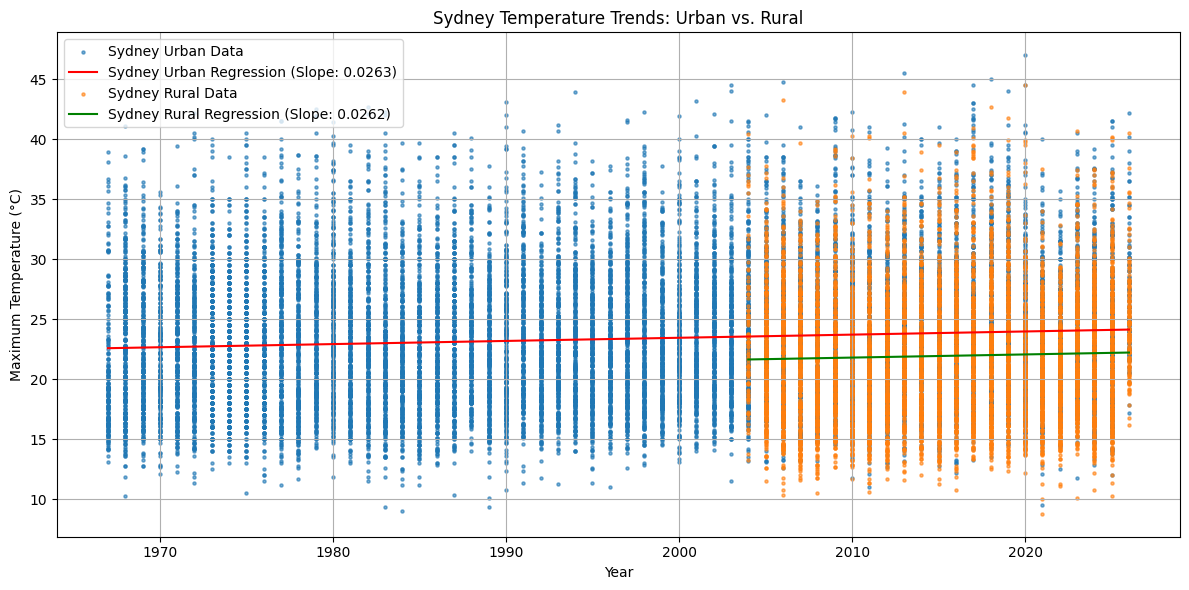

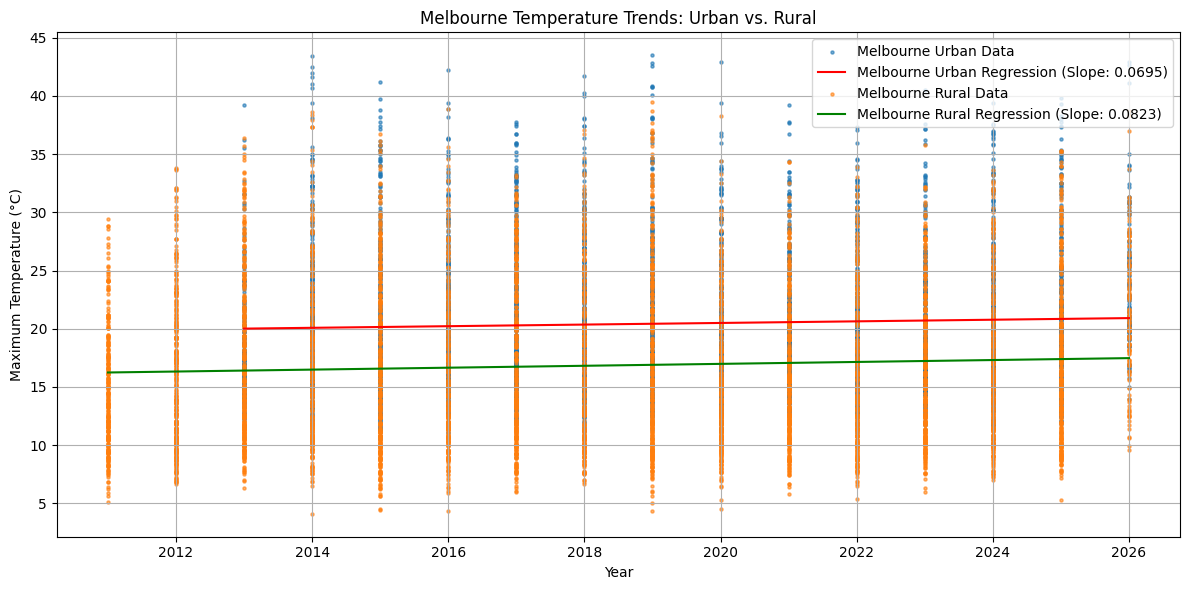

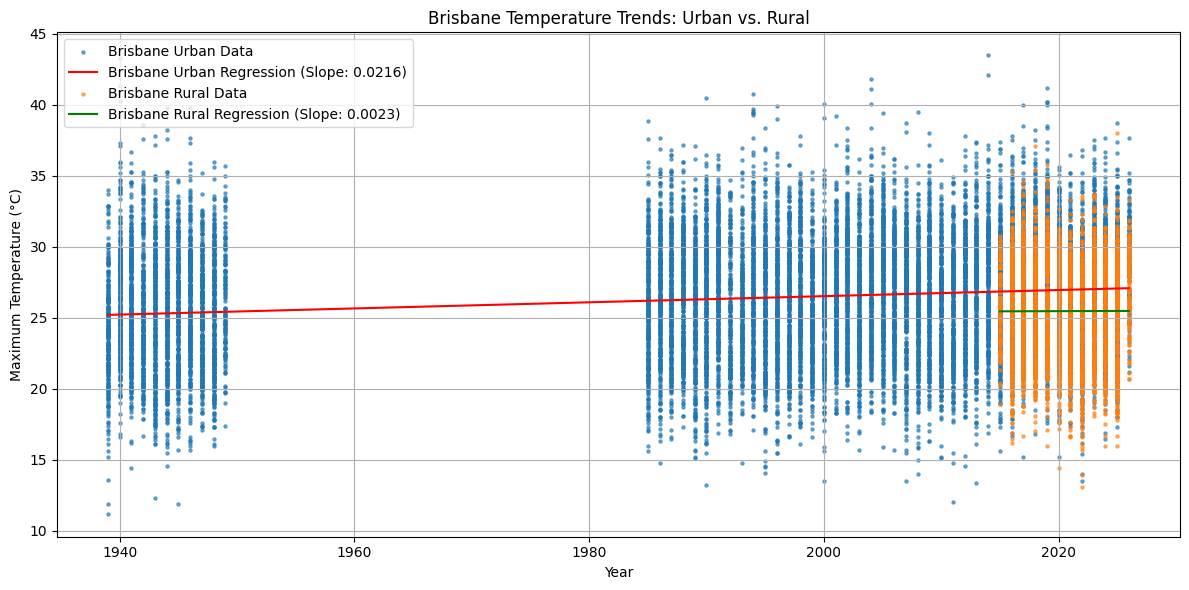

In [9]:
# Plot linear regressions for Sydney
plt.figure(figsize=(12, 6))

# Sydney Urban
x_urban_sydney = np.array(S_t_urban)
y_urban_sydney = np.array(S_urban_temp)
slope_u_sydney = S_urban_fit.slope
intercept_u_sydney = S_urban_fit.intercept
x_line_u_sydney = np.linspace(min(x_urban_sydney), max(x_urban_sydney), 100)
y_line_u_sydney = slope_u_sydney * x_line_u_sydney + intercept_u_sydney
plt.scatter(x_urban_sydney, y_urban_sydney, s=5, alpha=0.6, label='Sydney Urban Data')
plt.plot(x_line_u_sydney, y_line_u_sydney, color='red', label=f'Sydney Urban Regression (Slope: {slope_u_sydney:.4f})')

# Sydney Rural
x_rural_sydney = np.array(S_t_rural)
y_rural_sydney = np.array(S_rural_temp)
slope_r_sydney = S_rural_fit.slope
intercept_r_sydney = S_rural_fit.intercept
x_line_r_sydney = np.linspace(min(x_rural_sydney), max(x_rural_sydney), 100)
y_line_r_sydney = slope_r_sydney * x_line_r_sydney + intercept_r_sydney
plt.scatter(x_rural_sydney, y_rural_sydney, s=5, alpha=0.6, label='Sydney Rural Data')
plt.plot(x_line_r_sydney, y_line_r_sydney, color='green', label=f'Sydney Rural Regression (Slope: {slope_r_sydney:.4f})')

plt.title('Sydney Temperature Trends: Urban vs. Rural')
plt.xlabel('Year')
plt.ylabel('Maximum Temperature (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot linear regressions for Melbourne
plt.figure(figsize=(12, 6))

# Melbourne Urban
x_urban_melbourne = np.array(M_t_urban)
y_urban_melbourne = np.array(M_urban_temp)
slope_u_melbourne = M_urban_fit.slope
intercept_u_melbourne = M_urban_fit.intercept
x_line_u_melbourne = np.linspace(min(x_urban_melbourne), max(x_urban_melbourne), 100)
y_line_u_melbourne = slope_u_melbourne * x_line_u_melbourne + intercept_u_melbourne
plt.scatter(x_urban_melbourne, y_urban_melbourne, s=5, alpha=0.6, label='Melbourne Urban Data')
plt.plot(x_line_u_melbourne, y_line_u_melbourne, color='red', label=f'Melbourne Urban Regression (Slope: {slope_u_melbourne:.4f})')

# Melbourne Rural
x_rural_melbourne = np.array(M_t_rural)
y_rural_melbourne = np.array(M_rural_temp)
slope_r_melbourne = M_rural_fit.slope
intercept_r_melbourne = M_rural_fit.intercept
x_line_r_melbourne = np.linspace(min(x_rural_melbourne), max(x_rural_melbourne), 100)
y_line_r_melbourne = slope_r_melbourne * x_line_r_melbourne + intercept_r_melbourne
plt.scatter(x_rural_melbourne, y_rural_melbourne, s=5, alpha=0.6, label='Melbourne Rural Data')
plt.plot(x_line_r_melbourne, y_line_r_melbourne, color='green', label=f'Melbourne Rural Regression (Slope: {slope_r_melbourne:.4f})')

plt.title('Melbourne Temperature Trends: Urban vs. Rural')
plt.xlabel('Year')
plt.ylabel('Maximum Temperature (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot linear regressions for Brisbane
plt.figure(figsize=(12, 6))

# Brisbane Urban
x_urban_brisbane = np.array(B_t_urban)
y_urban_brisbane = np.array(B_urban_temp)
slope_u_brisbane = B_urban_fit.slope
intercept_u_brisbane = B_urban_fit.intercept
x_line_u_brisbane = np.linspace(min(x_urban_brisbane), max(x_urban_brisbane), 100)
y_line_u_brisbane = slope_u_brisbane * x_line_u_brisbane + intercept_u_brisbane
plt.scatter(x_urban_brisbane, y_urban_brisbane, s=5, alpha=0.6, label='Brisbane Urban Data')
plt.plot(x_line_u_brisbane, y_line_u_brisbane, color='red', label=f'Brisbane Urban Regression (Slope: {slope_u_brisbane:.4f})')

# Brisbane Rural
x_rural_brisbane = np.array(B_t_rural)
y_rural_brisbane = np.array(B_rural_temp)
slope_r_brisbane = B_rural_fit.slope
intercept_r_brisbane = B_rural_fit.intercept
x_line_r_brisbane = np.linspace(min(x_rural_brisbane), max(x_rural_brisbane), 100)
y_line_r_brisbane = slope_r_brisbane * x_line_r_brisbane + intercept_r_brisbane
plt.scatter(x_rural_brisbane, y_rural_brisbane, s=5, alpha=0.6, label='Brisbane Rural Data')
plt.plot(x_line_r_brisbane, y_line_r_brisbane, color='green', label=f'Brisbane Rural Regression (Slope: {slope_r_brisbane:.4f})')

plt.title('Brisbane Temperature Trends: Urban vs. Rural')
plt.xlabel('Year')
plt.ylabel('Maximum Temperature (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# Extract slopes and standard errors (Sydney)
S_beta_u = S_urban_fit.slope
S_se_u = S_urban_fit.stderr

S_beta_r = S_rural_fit.slope
S_se_r = S_rural_fit.stderr

# Extract slopes and standard errors (Melbourne)
M_beta_u = M_urban_fit.slope
M_se_u = M_urban_fit.stderr

M_beta_r = M_rural_fit.slope
M_se_r = M_rural_fit.stderr

# Extract slopes and standard errors (Brisbane)
B_beta_u = B_urban_fit.slope
B_se_u = B_urban_fit.stderr

B_beta_r = B_rural_fit.slope
B_se_r = B_rural_fit.stderr

# Simulate posterior distributions
n_samples = 100000

S_beta_u_samples = np.random.normal(S_beta_u, S_se_u, n_samples) #creates 100,000 random samples of warming rates
S_beta_r_samples = np.random.normal(S_beta_r, S_se_r, n_samples)

M_beta_u_samples = np.random.normal(M_beta_u, M_se_u, n_samples) #creates 100,000 random samples of warming rates
M_beta_r_samples = np.random.normal(M_beta_r, M_se_r, n_samples)

B_beta_u_samples = np.random.normal(B_beta_u, B_se_u, n_samples) #creates 100,000 random samples of warming rates
B_beta_r_samples = np.random.normal(B_beta_r, B_se_r, n_samples)

# Probability urban warming faster (Sydney)
S_prob = np.mean(S_beta_u_samples > S_beta_r_samples) #probability that out of the 100,000 random samples, the urban warms faster
# Probability urban warming faster (Melbourne)
M_prob = np.mean(M_beta_u_samples > M_beta_r_samples)
# Probability urban warming faster (Brisbane)
B_prob = np.mean(B_beta_u_samples > B_beta_r_samples)

print(f"Probability Sydney urban warming faster = {S_prob:.3f}")
print(f"Probability Melbourne urban warming faster = {M_prob:.3f}")
print(f"Probability Brisbnae urban warming faster = {B_prob:.3f}")

Probability Sydney urban warming faster = 0.503
Probability Melbourne urban warming faster = 0.340
Probability Brisbnae urban warming faster = 0.862


To visually plot this, I plotted all the urban and rural samples that were the calculated posterior distributions as a histogram. The blue histograms represent the urban stations whilst the orange represents the chosen rural stations. On the x-axis and y-axis is the warming rate of each sample in degrees celcius and the frequency of the given warming rate respectivelly.

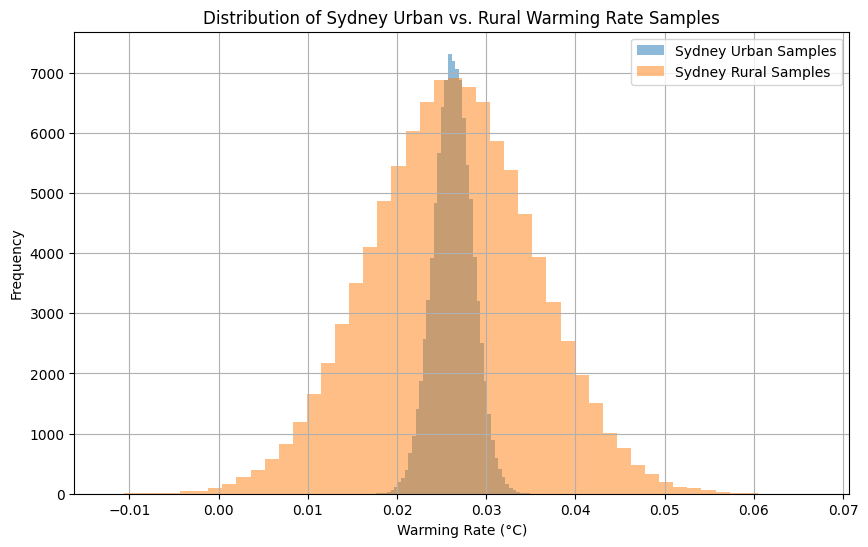

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(S_beta_u_samples, bins=50, alpha=0.5, label='Sydney Urban Samples')
plt.hist(S_beta_r_samples, bins=50, alpha=0.5, label='Sydney Rural Samples')
plt.title('Distribution of Sydney Urban vs. Rural Warming Rate Samples')
plt.xlabel('Warming Rate (\N{DEGREE SIGN}C)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

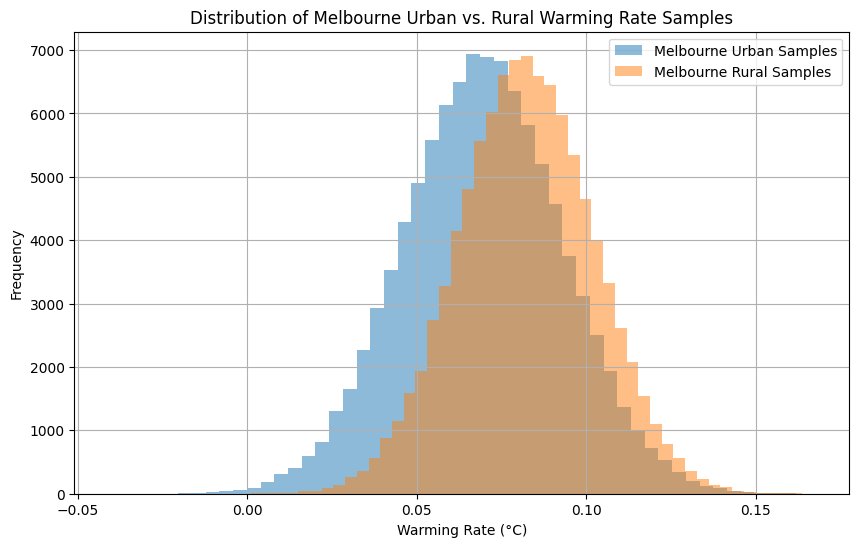

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(M_beta_u_samples, bins=50, alpha=0.5, label='Melbourne Urban Samples')
plt.hist(M_beta_r_samples, bins=50, alpha=0.5, label='Melbourne Rural Samples')
plt.title('Distribution of Melbourne Urban vs. Rural Warming Rate Samples')
plt.xlabel('Warming Rate (\N{DEGREE SIGN}C)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()


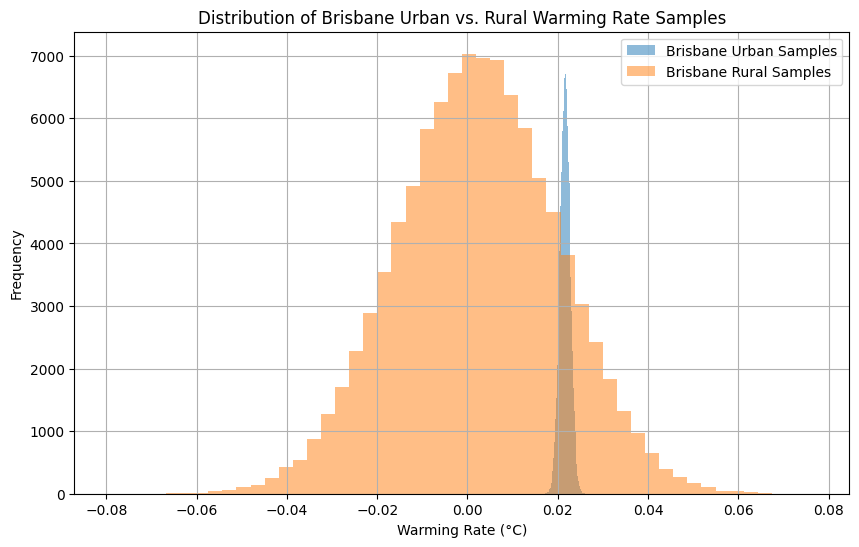

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(B_beta_u_samples, bins=50, alpha=0.5, label='Brisbane Urban Samples')
plt.hist(B_beta_r_samples, bins=50, alpha=0.5, label='Brisbane Rural Samples')
plt.title('Distribution of Brisbane Urban vs. Rural Warming Rate Samples')
plt.xlabel('Warming Rate (\N{DEGREE SIGN}C)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

**Interpretation**

The results show a wide range in the probability that the chosen cities are warming faster or slower than their rural counterparts. Melbourne has the lowest probability, with the urban station (Olympic Park) warming faster than the rural station only 33.8% of the time. Sydney sits close to 50/50, with Parramatta warming faster than its rural counterpart 50.2% of the time. Brisbane shows the highest probability, with its urban station warming faster than the rural station 86.2% of the time.

Based on the histogram plots, the samples appear normally distributed. For Sydney, although the urban station has a smaller standard deviation than the rural station, their means are very similar. This suggests that future warming rates at Parramatta can be predicted with more confidence than those at Terrey Hills, where there is greater variability in projected warming rates. A similar pattern is seen in Brisbane, where the urban station's warming rate distribution is considerably narrower than that of the rural station (Redland), and is centred at a higher mean (0.0216 compared to 0.0023). This suggests the Brisbane urban station is likely experiencing a faster warming rate than its surrounding rural areas. Melbourne, on the other hand, shows similar distributions for both its urban and rural stations, which is consistent with its lower probability result.

There are several uncertainties within these results. Daily maximum temperature data from BOM stations is limited by the physical placement of those stations, meaning areas that may better capture the extent of the UHI effect — such as far western Sydney or locations within national parks — cannot be included in the analysis. The time period over which data was collected may have also influenced the results, as stations with records beginning in the 1980s versus the 2010s would produce different warming rates, meaning the analysis may not reflect the most current warming trends. Additionally, the warming rates of each station are likely influenced by their proximity to the coast. Since Sydney, Melbourne, and Brisbane are all coastal cities, sea breezes and the ocean's high heat capacity act to regulate surface temperatures, which may partially offset or mask the UHI effect in the recorded data.

**Reflection**

In this individual project, I used what was taught in week 7 and 8 to predict the probability at which Australian cities were warming faster than its rural surroundings. What motivated me to investigate this question was to better understand how cities are acting as urban heat island’s (UHI). Considering that temperatures across the globe have been rising over time due to anthropogenic climate change, exacerbated temperatures due to urban materials and the lack of vegetation is going to amplify the impacts of increasing temperatures for millions of people living in urban areas. UHI effects have been studied for many cities around the globe, with megacities most focused on. This made me curious on seeing to what extent Australian cities, that have relatively small population sizes compared to megacities, are acting as UHI’s and how much warming they are becoming compared to rural areas.

Initially, I had issues with importing the data I was hoping to use as it had already been downloaded from a previous course. This data was a xarray dataset of ERA5 reanalysis observations of surface temperature, which would have allowed myself to analyse the observed temperature at any point in Australia. However, this data took a long time to upload into colab, which would have made it much less accessible for anyone else having to wait for the data to download and then additionally waiting longer for it to upload. I then decided to use daily maximum temperature data from the Bureau of Meteorology climate data site. This restricted the locations in which I could analyse but took much less time to download and upload into Colab. I also played around with what stations I used, as the temperature data for both urban and rural stations for the regions I chose varied greatly.

To answer my question, I used regression and sampling of posterior distribution techniques to sample warming rates of each of the locations I downloaded data for, where I could then compare the urban samples to the rural samples, and thus calculate how often the urban warming rate samples exceed that of the rural samples. Again, I accounted issues with loading time as sampling with the PyMC package was taking too long to load. I rectified this by calculating a linear regression instead. This does assume that temperature is changing over time on a linear scale, but took much quicker to load.

In the end I was able to provide values to my questions for each location and visually represent this data on histograms. However, the results I got did not necessarily match up with my hypothesis, where the analysis showed that some urban areas are warming slower than their rural areas. This may not be wrong, but does confirm some shortcomings in the final analysis. These limitations included the locations are which I could download temperature data, as well as varying time frames in when this data was collected.
